1. Setup and Data Loading

Loaded 100,836 ratings across 610 users and 9724 movies.
Train: 80,668  |  Test: 20,168  |  Global mean: 3.5026


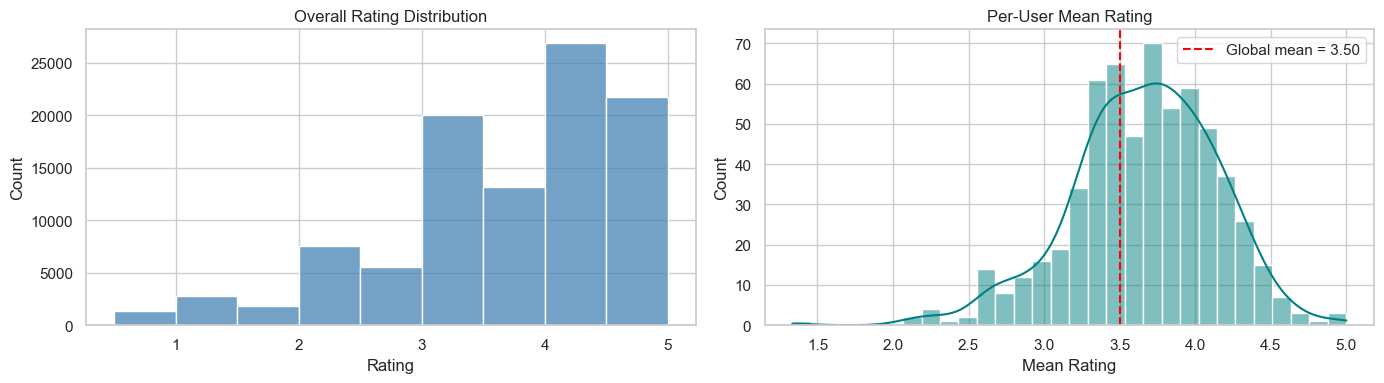

In [7]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MultiLabelBinarizer
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
%matplotlib inline

DATA_DIR   = Path('../../dataset')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies  = pd.read_csv(DATA_DIR / 'movies.csv')

train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

global_mean = float(train_df['rating'].mean())
print(f'Loaded {len(ratings):,} ratings across {ratings["userId"].nunique()} users and {ratings["movieId"].nunique()} movies.')
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}  |  Global mean: {global_mean:.4f}')

# Rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(ratings['rating'], bins=9, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Overall Rating Distribution')
axes[0].set_xlabel('Rating')

user_means = train_df.groupby('userId')['rating'].mean()
sns.histplot(user_means, bins=30, kde=True, color='teal', ax=axes[1])
axes[1].axvline(global_mean, color='red', linestyle='--', label=f'Global mean = {global_mean:.2f}')
axes[1].set_title('Per-User Mean Rating')
axes[1].set_xlabel('Mean Rating')
axes[1].legend()
plt.tight_layout()
plt.show()

2. Rating Matrix & Sparsity

Matrix shape : 610 users x 8983 movies
Sparsity     : 98.53%  (80,668 rated out of 5,479,630 possible)


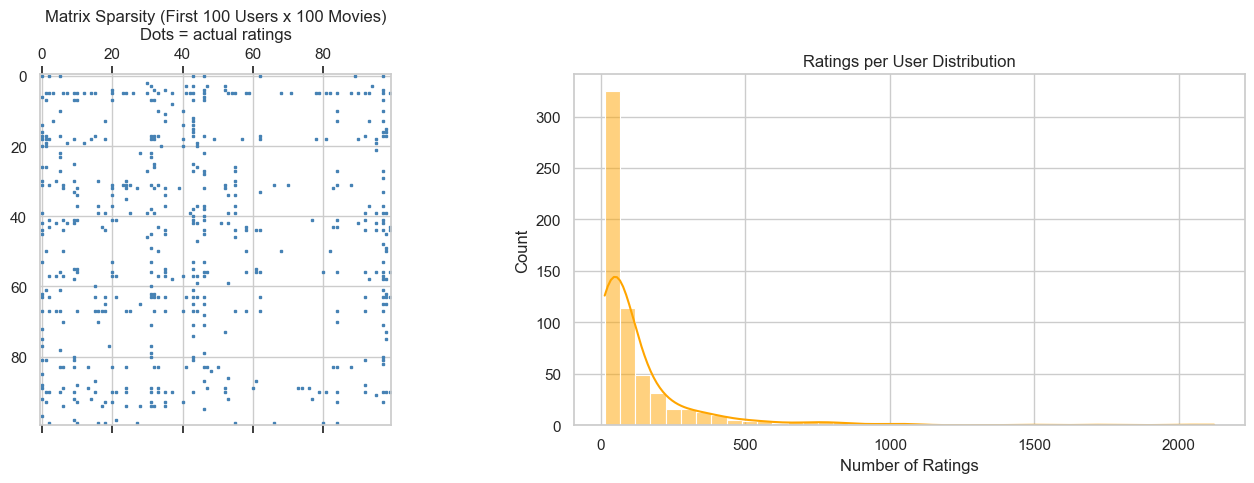

In [8]:
matrix = train_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)
matrix_vals = matrix.values.astype(float)

total_cells = matrix_vals.shape[0] * matrix_vals.shape[1]
filled_cells = (matrix_vals != 0).sum()
sparsity = 1 - filled_cells / total_cells
print(f'Matrix shape : {matrix_vals.shape[0]} users x {matrix_vals.shape[1]} movies')
print(f'Sparsity     : {sparsity:.2%}  ({filled_cells:,} rated out of {total_cells:,} possible)')

# Spy plot of a 100x100 slice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].spy(matrix.iloc[:100, :100], markersize=1.5, color='steelblue')
axes[0].set_title('Matrix Sparsity (First 100 Users x 100 Movies)\nDots = actual ratings')

# Ratings per user vs ratings per movie
ratings_per_user  = train_df.groupby('userId').size()
ratings_per_movie = train_df.groupby('movieId').size()
sns.histplot(ratings_per_user, bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Ratings per User Distribution')
axes[1].set_xlabel('Number of Ratings')
plt.tight_layout()
plt.show()

3. Feature Engineering

In [9]:
# Bias statistics
user_stats  = train_df.groupby('userId')['rating'].agg(user_mean='mean',  user_count='count')
movie_stats = train_df.groupby('movieId')['rating'].agg(movie_mean='mean', movie_count='count')

# Genre one-hot
movies['genre_list'] = movies['genres'].apply(lambda g: g.split('|') if g != '(no genres listed)' else [])
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies['genre_list'])
genre_df   = pd.DataFrame(genre_matrix, columns=[f'genre_{g}' for g in mlb.classes_])
genre_df['movieId'] = movies['movieId'].values
genre_cols = [c for c in genre_df.columns if c != 'movieId']

# SVD latent user taste
print('Computing SVD...')
user_index  = {uid: i for i, uid in enumerate(matrix.index)}
counts      = (matrix_vals != 0).sum(1)
row_means   = np.where(counts > 0, matrix_vals.sum(1) / np.maximum(counts, 1), global_mean)
matrix_centred = matrix_vals.copy()
for i in range(matrix_centred.shape[0]):
    mask = matrix_centred[i] != 0
    matrix_centred[i, mask] -= row_means[i]

svd      = TruncatedSVD(n_components=50, random_state=42)
U_sigma  = svd.fit_transform(matrix_centred)
svd_cols = [f'svd_{i}' for i in range(U_sigma.shape[1])]
svd_user_df = pd.DataFrame(U_sigma, index=matrix.index, columns=svd_cols).reset_index()

feat_cols = ['user_mean', 'user_count', 'movie_mean', 'movie_count'] + svd_cols + genre_cols

def build_features(df):
    d = df[['userId', 'movieId']].copy()
    d = d.merge(user_stats,  on='userId',  how='left')
    d = d.merge(movie_stats, on='movieId', how='left')
    d = d.merge(svd_user_df, on='userId',  how='left')
    d = d.merge(genre_df,    on='movieId', how='left')
    d['user_mean']   = d['user_mean'].fillna(global_mean)
    d['user_count']  = d['user_count'].fillna(0)
    d['movie_mean']  = d['movie_mean'].fillna(global_mean)
    d['movie_count'] = d['movie_count'].fillna(0)
    d[svd_cols]   = d[svd_cols].fillna(0)
    d[genre_cols] = d[genre_cols].fillna(0)
    return d[feat_cols].values

X_train = build_features(train_df)
y_train = train_df['rating'].values
X_test  = build_features(test_df)
y_test  = test_df['rating'].values

print(f'Feature groups  : {len(["user_mean","user_count","movie_mean","movie_count"])} bias  |  {len(svd_cols)} SVD  |  {len(genre_cols)} genre  =  {len(feat_cols)} total')
print(f'X_train         : {X_train.shape}  |  X_test: {X_test.shape}')

Computing SVD...
Feature groups  : 4 bias  |  50 SVD  |  19 genre  =  73 total
X_train         : (80668, 73)  |  X_test: (20168, 73)


4. Visualizing Input Features

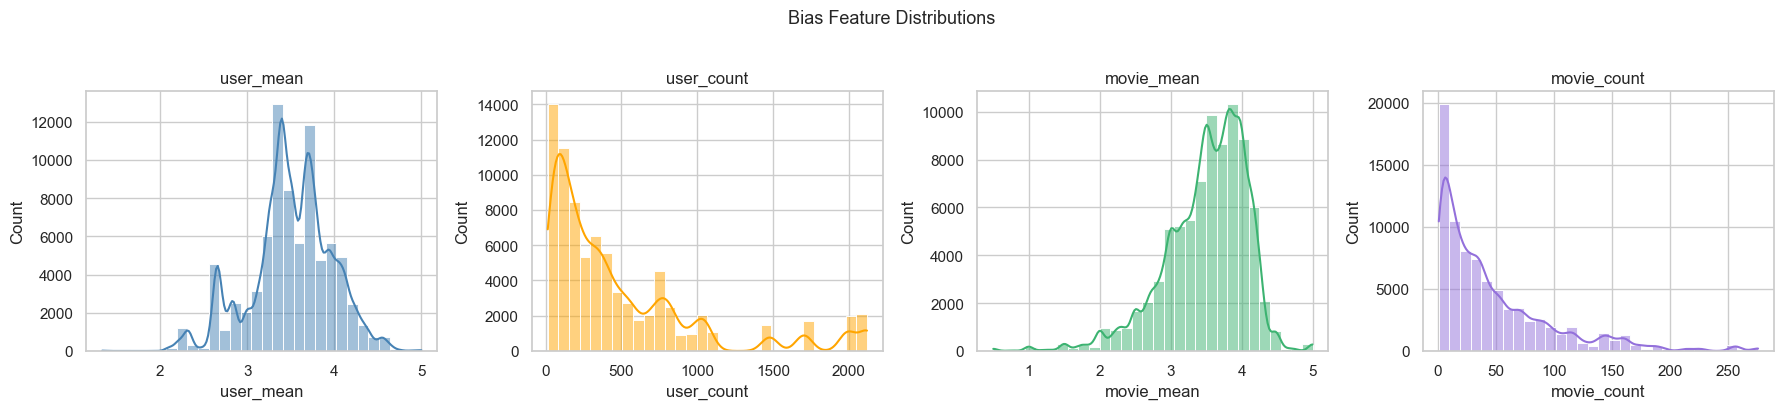

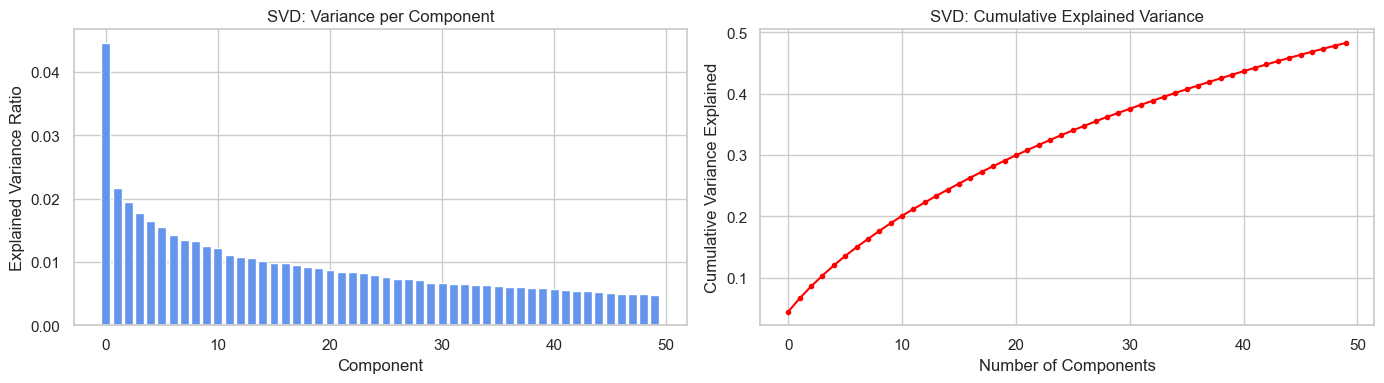

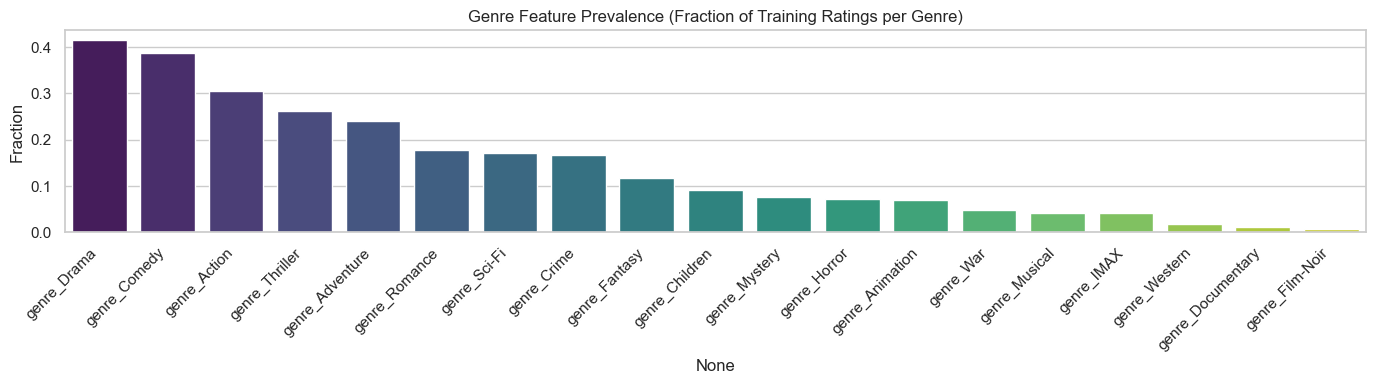

Raw Input Feature Sample (First 10 Rows)


,user_mean,user_count,movie_mean,movie_count,svd_0,svd_1,svd_2,svd_3,svd_4,svd_5
0,3.227,374.000,3.321,14.000,2.381,0.130,0.461,0.619,-1.032,0.335
1,4.040,126.000,4.250,4.000,0.358,-0.370,-0.177,0.080,0.067,0.228
2,3.407,383.000,3.628,82.000,7.063,-0.862,2.444,-2.307,-0.137,-0.197
3,3.683,1044.000,3.509,53.000,10.447,3.101,1.464,4.337,0.567,-1.467
4,3.425,366.000,3.192,26.000,-0.435,-0.502,1.266,-3.066,1.660,-1.621
5,2.985,595.000,2.875,4.000,6.605,-0.648,3.681,-0.671,-1.070,-2.843
6,3.499,409.000,3.500,1.000,-2.021,-0.527,0.070,0.405,-0.295,-1.258
7,3.989,47.000,4.196,102.000,0.372,0.041,0.116,0.218,0.018,-0.129
8,3.390,2122.000,3.500,11.000,26.572,-13.959,-29.336,-1.686,-6.069,-2.980
9,3.686,314.000,3.553,19.000,2.078,-1.258,1.661,-1.535,0.042,-1.514


In [10]:
feat_df = pd.DataFrame(X_train, columns=feat_cols)

# Bias features
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, color in zip(axes, ['user_mean', 'user_count', 'movie_mean', 'movie_count'],
                           ['steelblue', 'orange', 'mediumseagreen', 'mediumpurple']):
    sns.histplot(feat_df[col], bins=30, kde=True, color=color, ax=ax)
    ax.set_title(col)
plt.suptitle('Bias Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# SVD explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(svd.explained_variance_ratio_)), svd.explained_variance_ratio_, color='cornflowerblue')
axes[0].set_title('SVD: Variance per Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(np.cumsum(svd.explained_variance_ratio_), color='red', marker='o', markersize=3)
axes[1].set_title('SVD: Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
plt.tight_layout()
plt.show()

# Genre prevalence
genre_prevalence = feat_df[genre_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(14, 4))
sns.barplot(x=genre_prevalence.index, y=genre_prevalence.values, palette='viridis')
plt.title('Genre Feature Prevalence (Fraction of Training Ratings per Genre)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraction')
plt.tight_layout()
plt.show()

print('Raw Input Feature Sample (First 10 Rows)')
display(feat_df.iloc[:10, :10].style.background_gradient(cmap='coolwarm', axis=0).format('{:.3f}'))

5. Ridge Regression

Training Ridge...
Ridge  RMSE=0.8969  MAE=0.6851


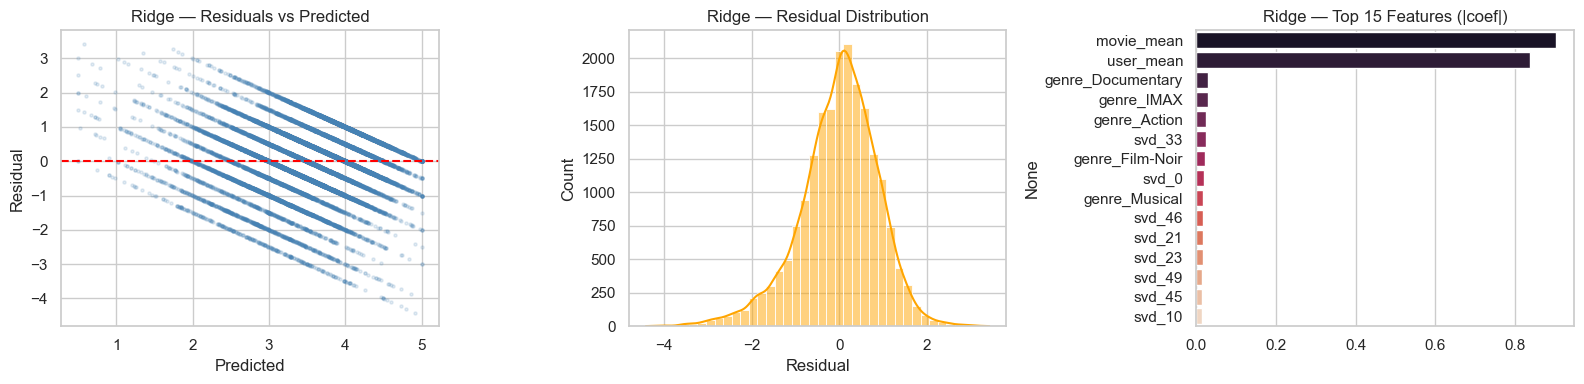

In [11]:
print('Training Ridge...')
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_preds = np.clip(ridge.predict(X_test), 0.5, 5.0)

rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
mae  = mean_absolute_error(y_test, ridge_preds)
print(f'Ridge  RMSE={rmse:.4f}  MAE={mae:.4f}')

residuals = y_test - ridge_preds
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(ridge_preds, residuals, alpha=0.15, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Ridge — Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Ridge — Residual Distribution')
axes[1].set_xlabel('Residual')

top15_ridge = pd.Series(np.abs(ridge.coef_), index=feat_cols).sort_values(ascending=False).head(15)
sns.barplot(x=top15_ridge.values, y=top15_ridge.index, palette='rocket', ax=axes[2])
axes[2].set_title('Ridge — Top 15 Features (|coef|)')
plt.tight_layout()
plt.show()

6. Random Forest

Training Random Forest...
Random Forest  RMSE=0.8816  MAE=0.6688


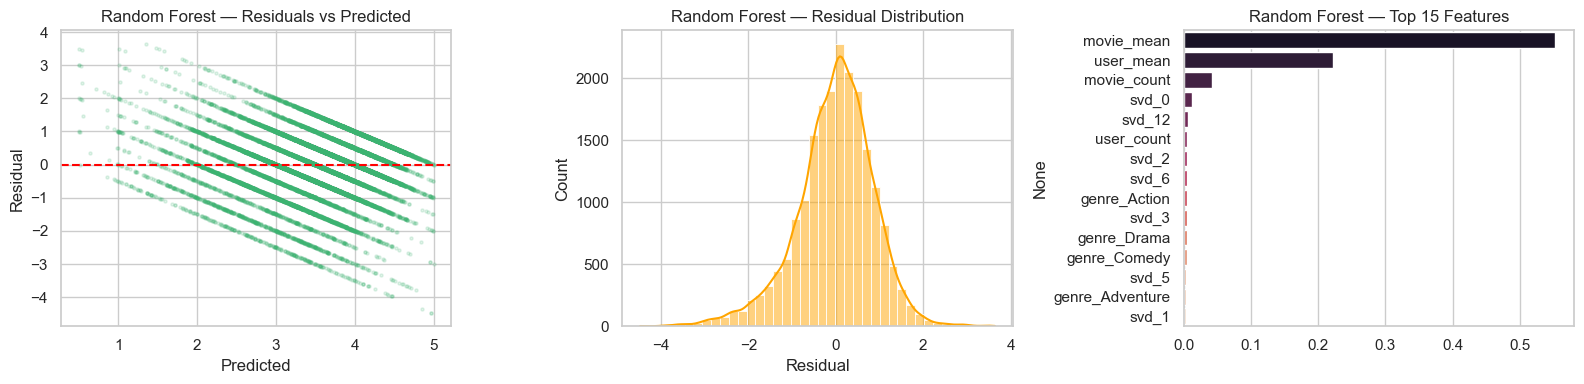

In [12]:
print('Training Random Forest...')
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=4, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = np.clip(rf.predict(X_test), 0.5, 5.0)

rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mae  = mean_absolute_error(y_test, rf_preds)
print(f'Random Forest  RMSE={rmse:.4f}  MAE={mae:.4f}')

residuals = y_test - rf_preds
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(rf_preds, residuals, alpha=0.15, s=5, color='mediumseagreen')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Random Forest — Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('Random Forest — Residual Distribution')
axes[1].set_xlabel('Residual')

top15_rf = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False).head(15)
sns.barplot(x=top15_rf.values, y=top15_rf.index, palette='rocket', ax=axes[2])
axes[2].set_title('Random Forest — Top 15 Features')
plt.tight_layout()
plt.show()

7. XGBoost

In [ ]:
print('Training XGBoost...')
xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = np.clip(xgb.predict(X_test), 0.5, 5.0)

rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
mae  = mean_absolute_error(y_test, xgb_preds)
print(f'XGBoost  RMSE={rmse:.4f}  MAE={mae:.4f}')

residuals = y_test - xgb_preds
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(xgb_preds, residuals, alpha=0.15, s=5, color='mediumpurple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('XGBoost — Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, bins=40, kde=True, color='orange', ax=axes[1])
axes[1].set_title('XGBoost — Residual Distribution')
axes[1].set_xlabel('Residual')

top15_xgb = pd.Series(xgb.feature_importances_, index=feat_cols).sort_values(ascending=False).head(15)
sns.barplot(x=top15_xgb.values, y=top15_xgb.index, palette='rocket', ax=axes[2])
axes[2].set_title('XGBoost — Top 15 Features')
plt.tight_layout()
plt.show()

8. Model Comparison

In [ ]:
models_map = {
    'Ridge':         ridge_preds,
    'Random Forest': rf_preds,
    'XGBoost':       xgb_preds,
}

perf_df = pd.DataFrame([
    {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, p)),
        'MAE':  mean_absolute_error(y_test, p),
    }
    for name, p in models_map.items()
]).set_index('Model')

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'mediumseagreen', 'mediumpurple']

for ax, metric in zip(axes, ['RMSE', 'MAE']):
    bars = ax.bar(perf_df.index, perf_df[metric], color=colors)
    for bar, val in zip(bars, perf_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{metric} (Lower is Better)')
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

# Predicted vs actual distribution overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, preds) in zip(axes, models_map.items()):
    sns.histplot(preds,  bins=18, kde=True, color='mediumpurple', alpha=0.6, label='Predicted', ax=ax)
    sns.histplot(y_test, bins=18, kde=True, color='salmon',       alpha=0.5, label='Actual',    ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Rating')
    ax.legend()
plt.suptitle('Predicted vs Actual Rating Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
best = perf_df['RMSE'].idxmin()
summary = pd.DataFrame({
    'Model':          ['Ridge', 'Random Forest', 'XGBoost'],
    'Type':           ['Linear', 'Ensemble (Bagging)', 'Ensemble (Boosting)'],
    'Primary Signal': ['Bias + Latent', 'Splits on all features', 'Additive residual fit'],
    'RMSE':           perf_df['RMSE'].values.round(4),
    'MAE':            perf_df['MAE'].values.round(4),
})
display(summary)
print(f'\nBest model: {best} (RMSE = {perf_df.loc[best, "RMSE"]:.4f})')